In [37]:
# Import libraries and configure paths for VS Code + Google Colab

import os
import sys
from pathlib import Path

# If the notebook is running on Google Colab, mount Google Drive
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = Path('/content/drive/MyDrive/House-Price-Prediction-ML')
else:
    PROJECT_DIR = Path.cwd()
    if PROJECT_DIR.name == "notebooks":
        PROJECT_DIR = PROJECT_DIR.parent

# Make paths stable
DATA_DIR = PROJECT_DIR / "data"
ASSETS_DIR = PROJECT_DIR / "assets"
NOTEBOOKS_DIR = PROJECT_DIR / "notebooks"

print("Project directory:", PROJECT_DIR)
print("Data directory exists:", DATA_DIR.exists())
print("Assets directory exists:", ASSETS_DIR.exists())

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, HTML, Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Make notebook font bigger and clearer
display(HTML("""
<style>
.jp-Notebook {
    font-size: 18px;
}
.jp-MarkdownOutput {
    font-size: 19px;
    line-height: 1.8;
}
.jp-RenderedHTMLCommon h1 {
    font-size: 36px;
}
.jp-RenderedHTMLCommon h2 {
    font-size: 29px;
}
.jp-RenderedHTMLCommon h3 {
    font-size: 24px;
}
table {
    font-size: 16px;
}
</style>
"""))

print("Libraries imported successfully")



Project directory: c:\Users\Mhmd Rayan\meWork\House-Price-Prediction-ML
Data directory exists: True
Assets directory exists: True


Libraries imported successfully


<div dir="rtl" style="
    max-width: 950px;
    margin: 30px auto;
    padding: 35px 45px;
    text-align: right;
    font-size: 22px;
    line-height: 1.9;
    background-color: #ffffff;
    color: #111111;
    font-weight: 600;
    border: 2px solid #d0d0d0;
    border-radius: 18px;
">

  <h1 style="text-align:center; font-size:38px; margin-bottom:25px; color:#000000; font-weight:800;">
    פרויקט במבוא למדעי הנתונים ולמידת מכונה
  </h1>

  <p align="center">
    <img src="../assets/Handasim.png" width="430">
  </p>

  <hr style="margin: 30px 0; border: 1px solid #cccccc;">

  <h2 style="font-size:30px; color:#000000; font-weight:800;">דף שער</h2>

  <p><b>שם הסטודנט:</b> מוחמד ריאן</p>
  <p><b>כיתה:</b> 50/2</p>
  <p><b>שנת לימודים:</b> 2026</p>
  <p><b>שם המורה:</b> אירנה</p>
  <p><b>שם הפרויקט:</b> חיזוי רמת מחיר של בתים בעזרת למידת מכונה</p>

  <h2 style="font-size:30px; margin-top:30px; color:#000000; font-weight:800;">שאלת המחקר</h2>

  <p>
    האם ניתן לחזות אם בית שייך לקבוצת מחיר גבוה או מחיר נמוך לפי מאפיינים פיזיים של הבית,
    כגון שטח מגורים, מספר חדרי רחצה, מספר חדרי שינה, מספר קומות, נוף ומצב הבית?
  </p>

  <h2 style="font-size:30px; margin-top:30px; color:#000000; font-weight:800;">תיאור כללי של הפרויקט</h2>

  <p>
    בפרויקט זה נשתמש בקובץ נתונים של בתים ונבצע תהליך מלא של מדעי הנתונים:
    טעינת הנתונים, חקר נתונים, ניקוי נתונים, הנדסת מאפיינים, בדיקת קורלציה,
    חלוקה לנתוני אימון ובדיקה, נירמול הנתונים, אימון מודל KNN ואימון מודל ANN.
  </p>

  <p>
    המטרה היא להפוך את עמודת המחיר מבעיה של רגרסיה לבעיה של סיווג,
    ולחזות האם הבית נמצא בקבוצת מחיר נמוך או בקבוצת מחיר גבוה.
  </p>

  <p align="center" style="margin-top:35px;">
    <img src="../assets/cover.png" width="760" style="border-radius: 16px;">
  </p>

</div>

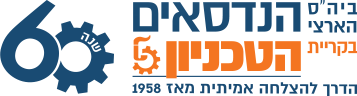

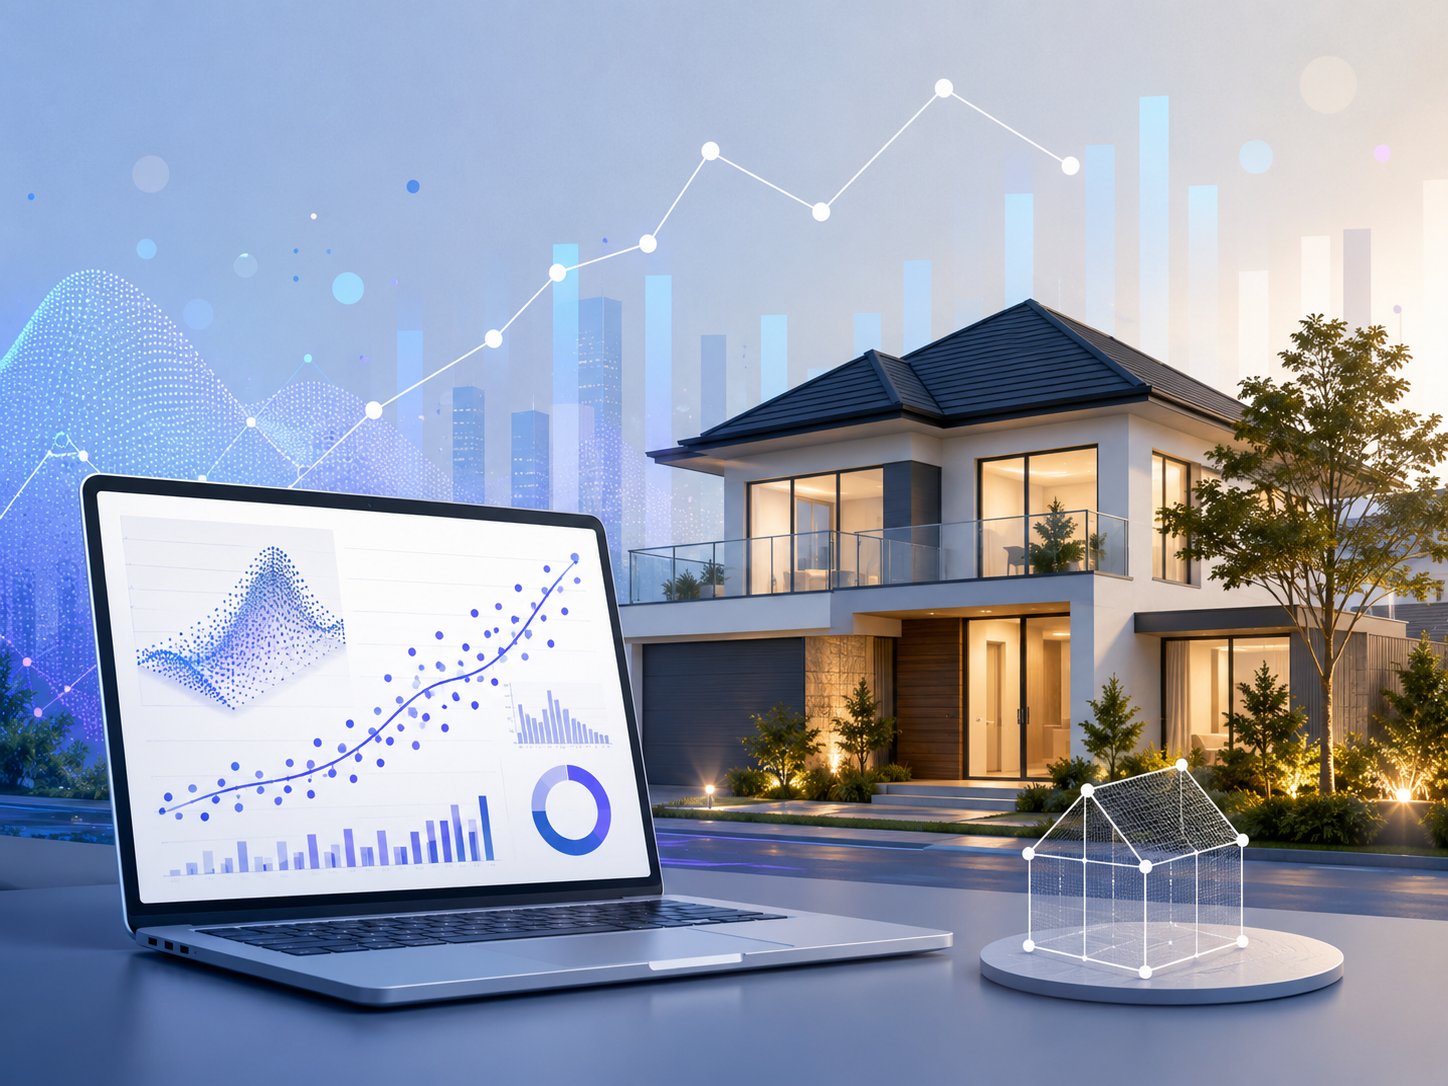

In [38]:
# Display project images in Colab / VS Code

logo_path = ASSETS_DIR / "Handasim.png"
cover_path = ASSETS_DIR / "cover.png"

if logo_path.exists():
    display(Image(filename=str(logo_path), width=430))
else:
    print("Logo image not found:", logo_path)

if cover_path.exists():
    display(Image(filename=str(cover_path), width=760))
else:
    print("Cover image not found:", cover_path)



<div dir="rtl" style=" max-width: 950px; margin: 25px auto; padding: 25px 40px; text-align: right; font-size: 21px; line-height: 1.9; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 16px; ">

<h1 style="color:#000000; font-weight:800;">1. טעינת הנתונים</h1>

<p>
בשלב זה נטען את קובץ הנתונים <b>data_House.csv</b> ונבדוק שהנתונים נקראו בצורה תקינה.
</p>

<p>
קובץ הנתונים נמצא בתיקייה:
</p>

<p style="direction:ltr; text-align:left;"><b>data/data_House.csv</b></p>

</div>

In [39]:
# Load dataset

from pathlib import Path

if "DATA_DIR" not in globals():
    PROJECT_DIR = Path.cwd()
    if PROJECT_DIR.name == "notebooks":
        PROJECT_DIR = PROJECT_DIR.parent
    DATA_DIR = PROJECT_DIR / "data"

if "pd" not in globals():
    import pandas as pd
    import numpy as np

data_path = DATA_DIR / "data_House.csv"

if not data_path.exists():
    raise FileNotFoundError(
        f"data_House.csv was not found at: {data_path}\n"
        "Make sure your Google Drive folder is: MyDrive/House-Price-Prediction-ML/data/data_House.csv"
    )

# Keep the original dataframe unchanged for the first EDA steps
df_original = pd.read_csv(data_path)
df = df_original.copy()

print("Dataset loaded successfully")
print("Dataset path:", data_path)
print("Dataset shape:", df.shape)

df.head()


Dataset loaded successfully
Dataset path: c:\Users\Mhmd Rayan\meWork\House-Price-Prediction-ML\data\data_House.csv
Dataset shape: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


<div dir="rtl" style=" max-width: 950px; margin: 15px auto 30px auto; padding: 18px 30px; text-align: right; font-size: 20px; line-height: 1.8; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 14px; ">

<b>מסקנה:</b>
קובץ הנתונים נטען בהצלחה. הנתונים כוללים 4600 רשומות ו־18 עמודות.
כל רשומה מייצגת בית אחד, וכל עמודה מייצגת מאפיין אחר של הבית.

</div>

<div dir="rtl" style=" max-width: 950px; margin: 25px auto; padding: 25px 40px; text-align: right; font-size: 21px; line-height: 1.9; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 16px; ">

<h1 style="color:#000000; font-weight:800;">2. תיאור הנתונים</h1>

<p>
קובץ הנתונים שבו נשתמש בפרויקט הוא <b>data_House.csv</b>.
הקובץ מכיל נתונים על בתים. כל שורה מייצגת בית אחד, וכל עמודה מייצגת מאפיין של הבית.
</p>

<p>
קישור למאגר הנתונים: <span style="direction:ltr; unicode-bidi:embed;">https://www.kaggle.com/datasets/shree1992/housedata</span>
</p>

<h2 style="color:#000000; font-weight:800;">הסבר על העמודות בקובץ המקורי</h2>

<table style="width:100%; border-collapse: collapse; font-size:18px;">
<tr style="background-color:#eeeeee;">
<th style="border:1px solid #999; padding:8px;">עמודה</th>
<th style="border:1px solid #999; padding:8px;">הסבר</th>
<th style="border:1px solid #999; padding:8px;">סוג נתון</th>
</tr>
<tr><td style="border:1px solid #999; padding:8px;">date</td><td style="border:1px solid #999; padding:8px;">תאריך מכירת הבית. בהמשך נמחק עמודה זו כי לא נשתמש בתאריך במודל.</td><td style="border:1px solid #999; padding:8px;">תאריך / טקסט</td></tr>
<tr><td style="border:1px solid #999; padding:8px;">price</td><td style="border:1px solid #999; padding:8px;">מחיר הבית. ממנו ניצור את עמודת המטרה Price_Level.</td><td style="border:1px solid #999; padding:8px;">רציף</td></tr>
<tr><td style="border:1px solid #999; padding:8px;">bedrooms</td><td style="border:1px solid #999; padding:8px;">מספר חדרי השינה בבית.</td><td style="border:1px solid #999; padding:8px;">בדיד</td></tr>
<tr><td style="border:1px solid #999; padding:8px;">bathrooms</td><td style="border:1px solid #999; padding:8px;">מספר חדרי הרחצה בבית.</td><td style="border:1px solid #999; padding:8px;">רציף</td></tr>
<tr><td style="border:1px solid #999; padding:8px;">sqft_living</td><td style="border:1px solid #999; padding:8px;">שטח המגורים של הבית ברגל רבוע.</td><td style="border:1px solid #999; padding:8px;">רציף</td></tr>
<tr><td style="border:1px solid #999; padding:8px;">sqft_lot</td><td style="border:1px solid #999; padding:8px;">שטח המגרש של הבית ברגל רבוע.</td><td style="border:1px solid #999; padding:8px;">רציף</td></tr>
<tr><td style="border:1px solid #999; padding:8px;">floors</td><td style="border:1px solid #999; padding:8px;">מספר הקומות בבית.</td><td style="border:1px solid #999; padding:8px;">בדיד / רציף</td></tr>
<tr><td style="border:1px solid #999; padding:8px;">waterfront</td><td style="border:1px solid #999; padding:8px;">האם הבית נמצא ליד מים. 0 = לא, 1 = כן.</td><td style="border:1px solid #999; padding:8px;">בדיד</td></tr>
<tr><td style="border:1px solid #999; padding:8px;">view</td><td style="border:1px solid #999; padding:8px;">רמת הנוף של הבית.</td><td style="border:1px solid #999; padding:8px;">בדיד / סדר</td></tr>
<tr><td style="border:1px solid #999; padding:8px;">condition</td><td style="border:1px solid #999; padding:8px;">מצב הבית.</td><td style="border:1px solid #999; padding:8px;">בדיד / סדר</td></tr>
<tr><td style="border:1px solid #999; padding:8px;">sqft_above</td><td style="border:1px solid #999; padding:8px;">שטח הבית מעל הקרקע.</td><td style="border:1px solid #999; padding:8px;">רציף</td></tr>
<tr><td style="border:1px solid #999; padding:8px;">sqft_basement</td><td style="border:1px solid #999; padding:8px;">שטח המרתף של הבית. ערך 0 אומר שאין מרתף.</td><td style="border:1px solid #999; padding:8px;">רציף</td></tr>
<tr><td style="border:1px solid #999; padding:8px;">yr_built</td><td style="border:1px solid #999; padding:8px;">שנת בניית הבית.</td><td style="border:1px solid #999; padding:8px;">בדיד</td></tr>
<tr><td style="border:1px solid #999; padding:8px;">yr_renovated</td><td style="border:1px solid #999; padding:8px;">שנת השיפוץ של הבית. ערך 0 אומר שהבית לא שופץ.</td><td style="border:1px solid #999; padding:8px;">בדיד</td></tr>
<tr><td style="border:1px solid #999; padding:8px;">street</td><td style="border:1px solid #999; padding:8px;">כתובת הרחוב. בהמשך נמחק עמודה זו כי היא טקסטואלית.</td><td style="border:1px solid #999; padding:8px;">שמי</td></tr>
<tr><td style="border:1px solid #999; padding:8px;">city</td><td style="border:1px solid #999; padding:8px;">שם העיר. בפרויקט זה נמחק עמודה זו לפי החלטת הפרויקט.</td><td style="border:1px solid #999; padding:8px;">שמי</td></tr>
<tr><td style="border:1px solid #999; padding:8px;">statezip</td><td style="border:1px solid #999; padding:8px;">מדינה ומיקוד. בפרויקט זה נמחק עמודה זו.</td><td style="border:1px solid #999; padding:8px;">שמי</td></tr>
<tr><td style="border:1px solid #999; padding:8px;">country</td><td style="border:1px solid #999; padding:8px;">מדינה. בפרויקט זה נמחק עמודה זו כי היא אינה מוסיפה מידע משמעותי למודל.</td><td style="border:1px solid #999; padding:8px;">שמי</td></tr>
</table>

</div>

<div dir="rtl" style=" max-width: 950px; margin: 25px auto; padding: 25px 40px; text-align: right; font-size: 21px; line-height: 1.9; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 16px; ">

<h1 style="color:#000000; font-weight:800;">3. בדיקת הנתונים הראשונית</h1>

<p>
בשלב זה נבדוק את מבנה הנתונים: מספר שורות ועמודות, סוגי הנתונים בכל עמודה,
כמות ערכים מלאים, כמות ערכים חסרים ומספר ערכים ייחודיים בכל עמודה.
</p>

</div>

In [40]:
# Initial data check

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nComplete records in each column:")
print(df.count())

print("\nNumber of unique values in each column:")
print(df.nunique())

Dataset shape:
(4600, 18)

Column names:
Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

Data types:
date                 str
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street               str
city                 str
statezip             str
country              str
dtype: object

Missing values:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above   

In [41]:
# Summary table for the dataset

summary_table = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Complete Records": df.count().values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

summary_table

,Column,Data Type,Complete Records,Missing Values,Unique Values
0,date,str,4600,0,70
1,price,float64,4600,0,1741
2,bedrooms,float64,4600,0,10
3,bathrooms,float64,4600,0,26
4,sqft_living,int64,4600,0,566
5,sqft_lot,int64,4600,0,3113
6,floors,float64,4600,0,6
7,waterfront,int64,4600,0,2
8,view,int64,4600,0,5
9,condition,int64,4600,0,5


<div dir="rtl" style=" max-width: 950px; margin: 15px auto 30px auto; padding: 18px 30px; text-align: right; font-size: 20px; line-height: 1.8; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 14px; ">

<b>מסקנה:</b>
מהבדיקה הראשונית ניתן לראות את סוג הנתון של כל עמודה, את מספר הערכים המלאים,
את מספר הערכים החסרים ואת מספר הערכים הייחודיים בכל עמודה.
בדיקה זו עוזרת להבין את מבנה הנתונים לפני בניית המודל.

</div>

<div dir="rtl" style=" max-width: 950px; margin: 25px auto; padding: 25px 40px; text-align: right; font-size: 21px; line-height: 1.9; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 16px; ">

<h1 style="color:#000000; font-weight:800;">4. חקר נתונים - Exploratory Data Analysis</h1>

<p>
בשלב זה נבצע חקר ראשוני של הנתונים.
נבדוק מדדים סטטיסטיים בסיסיים כמו ממוצע, סטיית תקן, ערך מינימלי, חציון וערך מקסימלי.
</p>

</div>

In [42]:
# Descriptive statistics

df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [43]:
# Descriptive statistics in a clearer table

df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
price,4600.0,551962.988473,563834.702547,0.0,322875.00,460943.461539,654962.50,26590000.0
bedrooms,4600.0,3.400870,0.908848,0.0,3.00,3.000000,4.00,9.0
bathrooms,4600.0,2.160815,0.783781,0.0,1.75,2.250000,2.50,8.0
sqft_living,4600.0,2139.346957,963.206916,370.0,1460.00,1980.000000,2620.00,13540.0
sqft_lot,4600.0,14852.516087,35884.436145,638.0,5000.75,7683.000000,11001.25,1074218.0
floors,4600.0,1.512065,0.538288,1.0,1.00,1.500000,2.00,3.5
waterfront,4600.0,0.007174,0.084404,0.0,0.00,0.000000,0.00,1.0
view,4600.0,0.240652,0.778405,0.0,0.00,0.000000,0.00,4.0
condition,4600.0,3.451739,0.677230,1.0,3.00,3.000000,4.00,5.0
sqft_above,4600.0,1827.265435,862.168977,370.0,1190.00,1590.000000,2300.00,9410.0


In [44]:
# Important statistics for price and living area

print("Price statistics:")
print("Mean price:", df['price'].mean())
print("Median price:", df['price'].median())
print("Minimum price:", df['price'].min())
print("Maximum price:", df['price'].max())

print("\nLiving area statistics:")
print("Mean sqft_living:", df['sqft_living'].mean())
print("Median sqft_living:", df['sqft_living'].median())
print("Minimum sqft_living:", df['sqft_living'].min())
print("Maximum sqft_living:", df['sqft_living'].max())

Price statistics:
Mean price: 551962.9884732141
Median price: 460943.46153850004
Minimum price: 0.0
Maximum price: 26590000.0

Living area statistics:
Mean sqft_living: 2139.3469565217392
Median sqft_living: 1980.0
Minimum sqft_living: 370
Maximum sqft_living: 13540


<div dir="rtl" style=" max-width: 950px; margin: 15px auto 30px auto; padding: 18px 30px; text-align: right; font-size: 20px; line-height: 1.8; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 14px; ">

<b>מסקנה:</b>
מהטבלה הסטטיסטית ניתן לראות את הערכים המרכזיים של הנתונים: ממוצע, סטיית תקן, מינימום, חציון ומקסימום.
עמודת <b>price</b> מייצגת את מחיר הבית, ועמודת <b>sqft_living</b> מייצגת את שטח המגורים.
בהמשך נשתמש בעמודת המחיר כדי ליצור עמודת מטרה חדשה בשם <b>Price_Level</b>.

</div>

<div dir="rtl" style=" max-width: 950px; margin: 25px auto; padding: 25px 40px; text-align: right; font-size: 21px; line-height: 1.9; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 16px; ">

<h1 style="color:#000000; font-weight:800;">5. ניקוי נתונים והנדסת מאפיינים</h1>

<p>
בשלב זה נבצע ניקוי נתונים ונכין את הנתונים ללמידת מכונה.
נמחק עמודות שלא נשתמש בהן במודל: <b>date</b>, <b>street</b>, <b>city</b>, <b>statezip</b>, <b>country</b>.
</p>

<p>
בנוסף, נבדוק אם קיימים ערכים חסרים. אם יהיו ערכים חסרים, נמלא אותם בעזרת החציון של אותה עמודה ולא נמחק שורות.
לאחר מכן נהפוך את עמודת <b>price</b> מבעיה של רגרסיה לבעיה של סיווג באמצעות <b>Price_Level</b>.
</p>

<ul>
  <li><b>0</b> = מחיר נמוך או שווה לחציון</li>
  <li><b>1</b> = מחיר גבוה מהחציון</li>
</ul>

</div>

In [45]:
# Data Cleaning and Feature Engineering

print("Shape before cleaning:", df.shape)

# Small check: count houses with price = 0
zero_price_count = (df['price'] == 0).sum()
print("Number of houses with price = 0:", zero_price_count)

# Delete columns that will not be used in the model
columns_to_delete = ['date', 'street', 'city', 'statezip', 'country']
df = df.drop(columns=columns_to_delete)

print("Shape after deleting columns:", df.shape)

# Check missing values
print("\nMissing values before filling:")
print(df.isnull().sum())

# Fill missing numeric values with median if needed
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("\nTotal missing values after cleaning:", df.isnull().sum().sum())

# Convert regression problem into classification problem
median_price = df['price'].median()
print("\nMedian price:", median_price)

df['Price_Level'] = (df['price'] > median_price).astype('int64')

# Drop original price column to prevent data leakage
df = df.drop('price', axis=1)

print("\nTarget balance:")
print(df['Price_Level'].value_counts())

df.head()

Shape before cleaning: (4600, 18)
Number of houses with price = 0: 49
Shape after deleting columns: (4600, 13)

Missing values before filling:
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
dtype: int64

Total missing values after cleaning: 0

Median price: 460943.46153850004

Target balance:
Price_Level
0    2300
1    2300
Name: count, dtype: int64


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,Price_Level
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,0
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,1
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,0
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,0
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,1


<div dir="rtl" style=" max-width: 950px; margin: 15px auto 30px auto; padding: 18px 30px; text-align: right; font-size: 20px; line-height: 1.8; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 14px; ">

<b>מסקנה:</b>
מחקנו רק עמודות שלא נשתמש בהן במודל ולא מחקנו שורות, ולכן נשארו 4600 רשומות.
לא נמצאו ערכים חסרים לאחר הניקוי. בנוסף, קיימים 49 בתים שבהם המחיר הוא 0, אך בפרויקט זה השארנו אותם כחלק מהנתונים המקוריים.
יצרנו את עמודת המטרה <b>Price_Level</b> לפי החציון של המחיר, והנתונים התחלקו לשתי קבוצות מאוזנות.

</div>

<div dir="rtl" style=" max-width: 950px; margin: 25px auto; padding: 25px 40px; text-align: right; font-size: 21px; line-height: 1.9; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 16px; ">

<h1 style="color:#000000; font-weight:800;">6. ויזואליזציה של הנתונים</h1>

<p>
בשלב זה נציג 5 גרפים שיעזרו להבין את הקשר בין מאפייני הבית לבין רמת המחיר.
בכל גרף נציין את סוג הנתונים ונסביר את המסקנה מתחת לגרף.
</p>

</div>

In [46]:
# Visualization settings

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["xtick.labelsize"] = 13
plt.rcParams["ytick.labelsize"] = 13

<div dir="rtl" style=" max-width: 950px; margin: 25px auto; padding: 25px 40px; text-align: right; font-size: 21px; line-height: 1.9; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 16px; ">
<h2 style="color:#000000; font-weight:800;">גרף 1: כמות הבתים בכל רמת מחיר</h2>
<p>סוג הנתונים: <b>בדיד</b>. העמודה <b>Price_Level</b> כוללת שתי קטגוריות: 0 = מחיר נמוך, 1 = מחיר גבוה.</p>
</div>

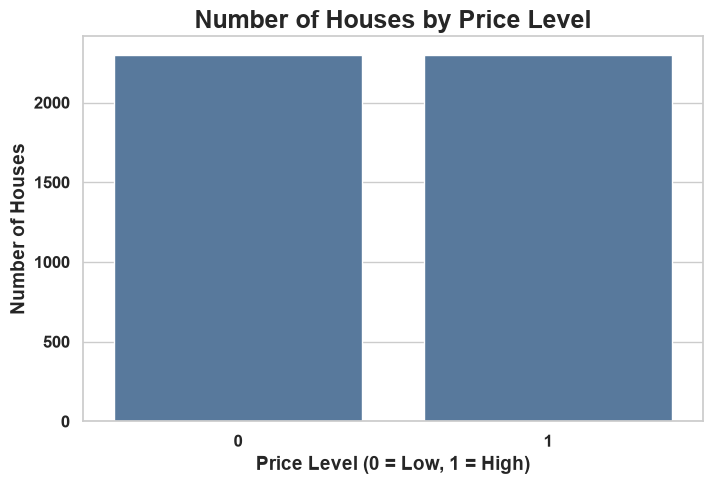

In [47]:
# Graph 1: Count plot of Price_Level

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Price_Level", color="#4C78A8")

plt.title("Number of Houses by Price Level", fontsize=18, fontweight="bold")
plt.xlabel("Price Level (0 = Low, 1 = High)", fontsize=14, fontweight="bold")
plt.ylabel("Number of Houses", fontsize=14, fontweight="bold")
plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

plt.show()

<div dir="rtl" style=" max-width: 950px; margin: 15px auto 30px auto; padding: 18px 30px; text-align: right; font-size: 20px; line-height: 1.8; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 14px; "><b>מסקנה:</b> ניתן לראות שהנתונים מאוזנים: יש מספר שווה של בתים בקבוצת המחיר הנמוך ובקבוצת המחיר הגבוה. לכן אין צורך לבצע איזון נתונים.</div>

<div dir="rtl" style=" max-width: 950px; margin: 25px auto; padding: 25px 40px; text-align: right; font-size: 21px; line-height: 1.9; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 16px; ">
<h2 style="color:#000000; font-weight:800;">גרף 2: התפלגות שטח המגורים</h2>
<p>סוג הנתונים: <b>רציף</b>. העמודה <b>sqft_living</b> מייצגת את שטח המגורים של הבית.</p>
</div>

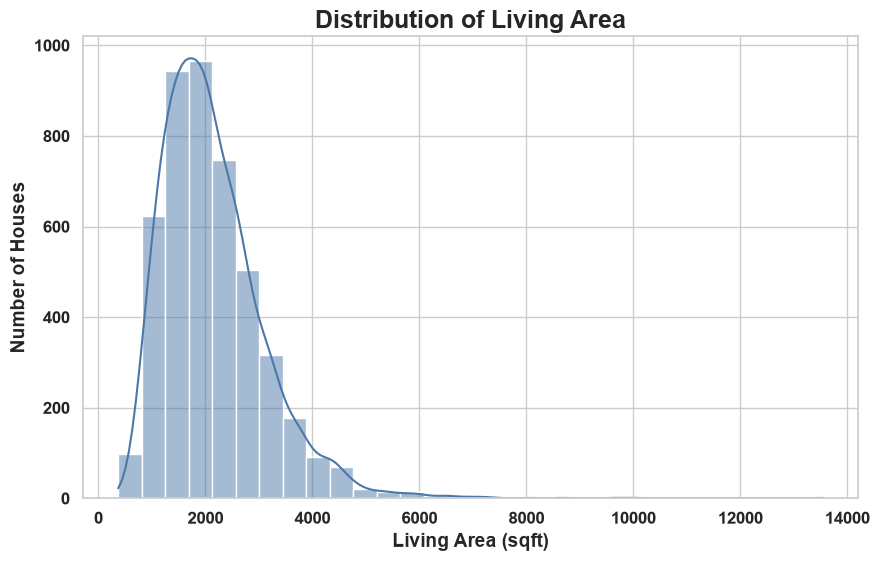

In [48]:
# Graph 2: Histogram of sqft_living

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="sqft_living", bins=30, kde=True, color="#4C78A8")

plt.title("Distribution of Living Area", fontsize=18, fontweight="bold")
plt.xlabel("Living Area (sqft)", fontsize=14, fontweight="bold")
plt.ylabel("Number of Houses", fontsize=14, fontweight="bold")
plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

plt.show()

<div dir="rtl" style=" max-width: 950px; margin: 15px auto 30px auto; padding: 18px 30px; text-align: right; font-size: 20px; line-height: 1.8; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 14px; "><b>מסקנה:</b> ניתן לראות שרוב הבתים נמצאים בטווח שטח מגורים מסוים, ויש פחות בתים עם שטח מגורים גדול מאוד. מאפיין זה חשוב כי שטח מגורים גדול יותר יכול להשפיע על רמת המחיר של הבית.</div>

<div dir="rtl" style=" max-width: 950px; margin: 25px auto; padding: 25px 40px; text-align: right; font-size: 21px; line-height: 1.9; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 16px; ">
<h2 style="color:#000000; font-weight:800;">גרף 3: שטח מגורים לפי רמת מחיר</h2>
<p>סוג הנתונים: <b>רציף + בדיד</b>. הגרף מציג את הקשר בין <b>sqft_living</b> לבין <b>Price_Level</b>.</p>
</div>

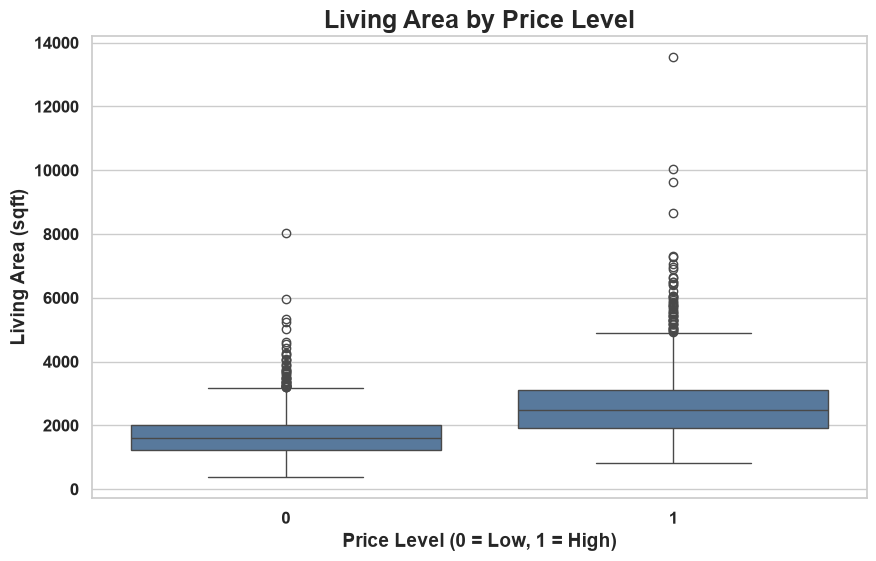

In [49]:
# Graph 3: Living area by price level

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Price_Level', y='sqft_living', color="#4C78A8")

plt.title('Living Area by Price Level', fontsize=18, fontweight='bold')
plt.xlabel('Price Level (0 = Low, 1 = High)', fontsize=14, fontweight='bold')
plt.ylabel('Living Area (sqft)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

plt.show()

<div dir="rtl" style=" max-width: 950px; margin: 15px auto 30px auto; padding: 18px 30px; text-align: right; font-size: 20px; line-height: 1.8; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 14px; "><b>מסקנה:</b> ניתן לראות שבתים בקבוצת המחיר הגבוה נוטים להיות בעלי שטח מגורים גדול יותר. לכן <b>sqft_living</b> הוא מאפיין חשוב לחיזוי רמת המחיר.</div>

<div dir="rtl" style=" max-width: 950px; margin: 25px auto; padding: 25px 40px; text-align: right; font-size: 21px; line-height: 1.9; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 16px; ">
<h2 style="color:#000000; font-weight:800;">גרף 4: ממוצע חדרי רחצה לפי רמת מחיר</h2>
<p>סוג הנתונים: <b>רציף + בדיד</b>. הגרף מציג את ממוצע מספר חדרי הרחצה בכל קבוצת מחיר.</p>
</div>

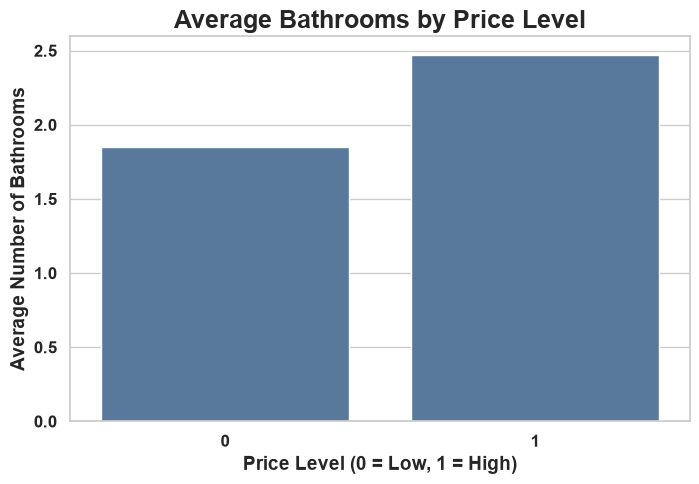

In [50]:
# Graph 4: Average bathrooms by Price_Level

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Price_Level", y="bathrooms", errorbar=None, color="#4C78A8")

plt.title("Average Bathrooms by Price Level", fontsize=18, fontweight="bold")
plt.xlabel("Price Level (0 = Low, 1 = High)", fontsize=14, fontweight="bold")
plt.ylabel("Average Number of Bathrooms", fontsize=14, fontweight="bold")
plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

plt.show()

<div dir="rtl" style=" max-width: 950px; margin: 15px auto 30px auto; padding: 18px 30px; text-align: right; font-size: 20px; line-height: 1.8; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 14px; "><b>מסקנה:</b> ניתן לראות שבתים בקבוצת המחיר הגבוה כוללים בממוצע יותר חדרי רחצה. לכן גם מספר חדרי הרחצה יכול לעזור למודל להבדיל בין מחיר נמוך למחיר גבוה.</div>

<div dir="rtl" style=" max-width: 950px; margin: 25px auto; padding: 25px 40px; text-align: right; font-size: 21px; line-height: 1.9; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 16px; ">
<h2 style="color:#000000; font-weight:800;">גרף 5: קשר בין שטח מגורים, חדרי רחצה ורמת מחיר</h2>
<p>סוג הנתונים: <b>שני משתנים רציפים + משתנה בדיד</b>. הגרף מציג את הקשר בין <b>sqft_living</b> ו־<b>bathrooms</b>, כאשר הצבע מייצג את רמת המחיר.</p>
</div>

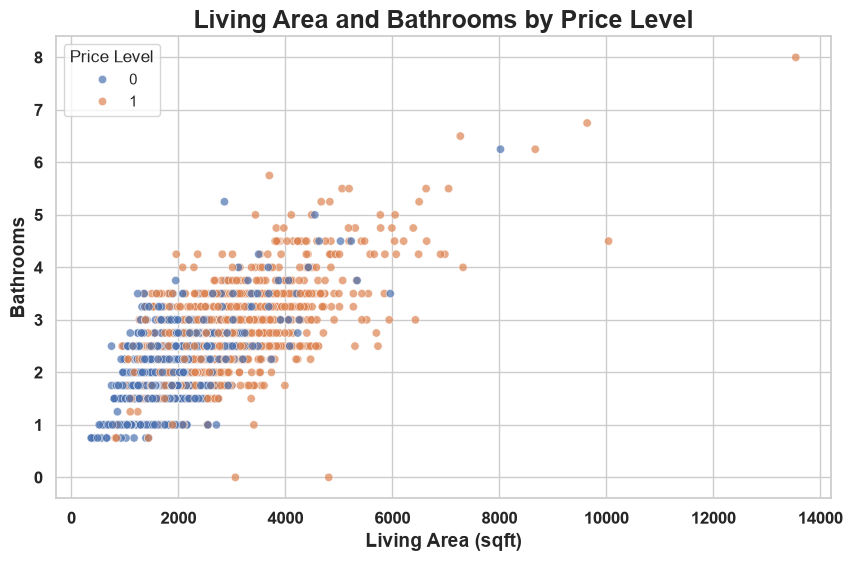

In [51]:
# Graph 5: Scatter plot of sqft_living and bathrooms by Price_Level

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="sqft_living",
    y="bathrooms",
    hue="Price_Level",
    alpha=0.7
)

plt.title("Living Area and Bathrooms by Price Level", fontsize=18, fontweight="bold")
plt.xlabel("Living Area (sqft)", fontsize=14, fontweight="bold")
plt.ylabel("Bathrooms", fontsize=14, fontweight="bold")
plt.legend(title="Price Level")
plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

plt.show()

<div dir="rtl" style=" max-width: 950px; margin: 15px auto 30px auto; padding: 18px 30px; text-align: right; font-size: 20px; line-height: 1.8; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 14px; "><b>מסקנה:</b> מהגרף ניתן לראות שבתים בעלי שטח מגורים גדול יותר ומספר חדרי רחצה גבוה יותר נוטים להופיע יותר בקבוצת המחיר הגבוה. מסקנה זו מתאימה לשאלת המחקר.</div>

<div dir="rtl" style=" max-width: 950px; margin: 25px auto; padding: 25px 40px; text-align: right; font-size: 21px; line-height: 1.9; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 16px; ">
<h1 style="color:#000000; font-weight:800;">7. בדיקת קורלציה</h1>
<p>בשלב זה נבדוק את הקורלציה בין המאפיינים השונים לבין עמודת המטרה <b>Price_Level</b>. קורלציה עוזרת להבין אילו מאפיינים קשורים יותר לרמת המחיר של הבית.</p>
</div>

In [52]:
# Correlation matrix

correlation_matrix = df.corr()

correlation_matrix

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,Price_Level
bedrooms,1.000000,0.545920,0.594884,0.068819,0.177895,-0.003483,0.111028,0.025080,0.484705,0.334165,0.142461,-0.061082,0.271276
bathrooms,0.545920,1.000000,0.761154,0.107837,0.486428,0.076232,0.211960,-0.119994,0.689918,0.298020,0.463498,-0.215886,0.397711
sqft_living,0.594884,0.761154,1.000000,0.210538,0.344850,0.117616,0.311009,-0.062826,0.876443,0.447206,0.287775,-0.122817,0.486774
sqft_lot,0.068819,0.107837,0.210538,1.000000,0.003750,0.017241,0.073907,0.000558,0.216455,0.034842,0.050706,-0.022730,0.085402
floors,0.177895,0.486428,0.344850,0.003750,1.000000,0.022024,0.031211,-0.275013,0.522814,-0.255510,0.467481,-0.233996,0.245773
waterfront,-0.003483,0.076232,0.117616,0.017241,0.022024,1.000000,0.360935,0.000352,0.078911,0.097501,-0.023563,0.008625,0.064397
view,0.111028,0.211960,0.311009,0.073907,0.031211,0.360935,1.000000,0.063077,0.174327,0.321602,-0.064465,0.022967,0.197471
condition,0.025080,-0.119994,-0.062826,0.000558,-0.275013,0.000352,0.063077,1.000000,-0.178196,0.200632,-0.399698,-0.186818,0.049439
sqft_above,0.484705,0.689918,0.876443,0.216455,0.522814,0.078911,0.174327,-0.178196,1.000000,-0.038723,0.408535,-0.160426,0.427464
sqft_basement,0.334165,0.298020,0.447206,0.034842,-0.255510,0.097501,0.321602,0.200632,-0.038723,1.000000,-0.161675,0.043125,0.216138


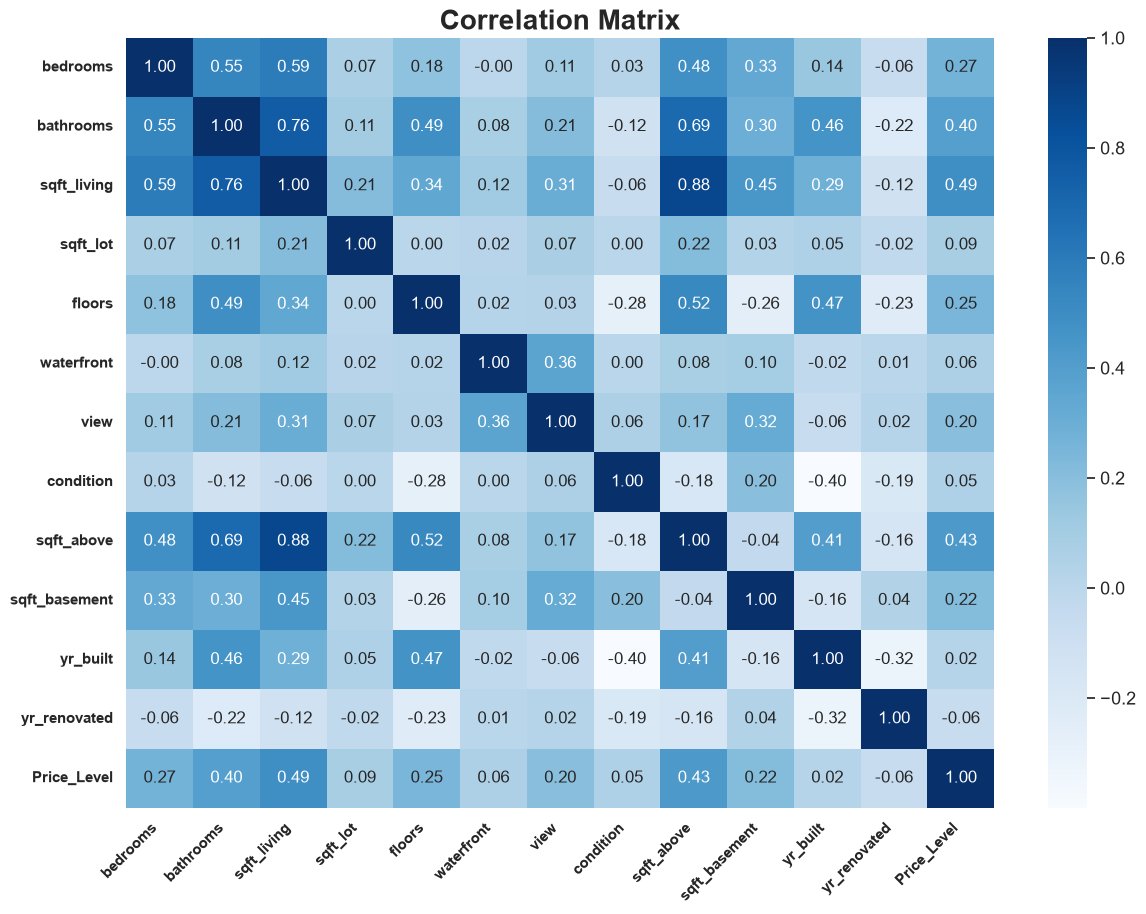

In [53]:
# Correlation heatmap

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Correlation Matrix", fontsize=20, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=11, fontweight="bold")
plt.yticks(fontsize=11, fontweight="bold")

plt.show()

<div dir="rtl" style=" max-width: 950px; margin: 15px auto 30px auto; padding: 18px 30px; text-align: right; font-size: 20px; line-height: 1.8; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 14px; "><b>מסקנה:</b> מפת הקורלציה מציגה את הקשר בין כל המאפיינים בטבלה. ניתן לראות שחלק מהמאפיינים קשורים יותר לרמת המחיר, במיוחד מאפיינים הקשורים לשטח הבית ולמספר חדרי הרחצה.</div>

In [54]:
# Correlation with target column Price_Level

target_correlation = df.corr()[["Price_Level"]].sort_values(
    by="Price_Level",
    ascending=False
)

target_correlation

,Price_Level
Price_Level,1.000000
sqft_living,0.486774
sqft_above,0.427464
bathrooms,0.397711
bedrooms,0.271276
floors,0.245773
sqft_basement,0.216138
view,0.197471
sqft_lot,0.085402
waterfront,0.064397


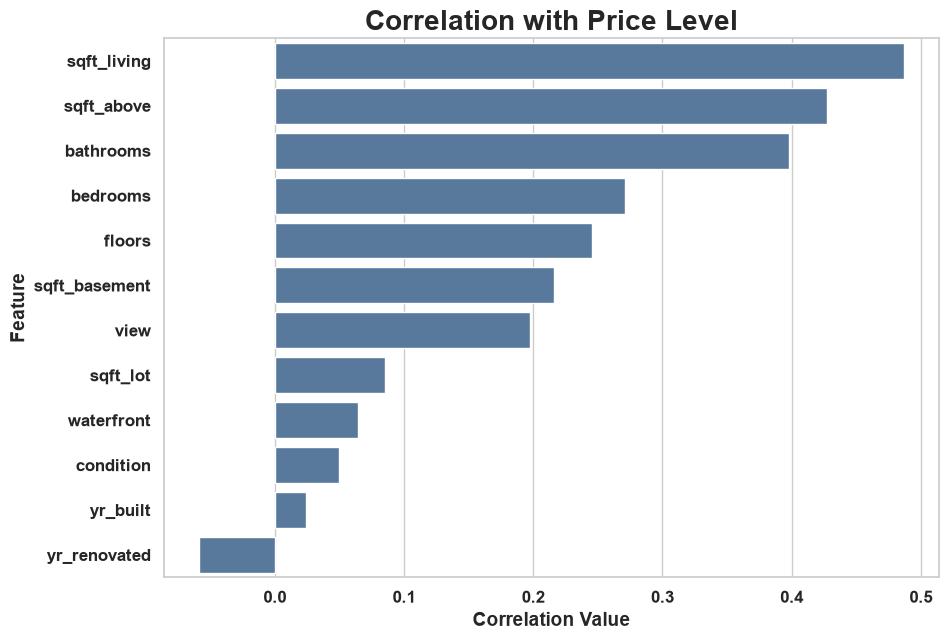

In [55]:
# Bar plot of correlation with Price_Level

target_correlation_without_target = target_correlation.drop("Price_Level")

plt.figure(figsize=(10, 7))

sns.barplot(
    data=target_correlation_without_target.reset_index(),
    x="Price_Level",
    y="index",
    color="#4C78A8"
)

plt.title("Correlation with Price Level", fontsize=20, fontweight="bold")
plt.xlabel("Correlation Value", fontsize=14, fontweight="bold")
plt.ylabel("Feature", fontsize=14, fontweight="bold")
plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

plt.show()

<div dir="rtl" style=" max-width: 950px; margin: 15px auto 30px auto; padding: 18px 30px; text-align: right; font-size: 20px; line-height: 1.8; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 14px; "><b>מסקנה:</b> לפי בדיקת הקורלציה, המאפיינים בעלי הקשר החזק ביותר לרמת המחיר הם בעיקר <b>sqft_living</b>, <b>sqft_above</b>, <b>bathrooms</b> ו־<b>bedrooms</b>. מסקנה זו מתאימה לשאלת המחקר.</div>

<div dir="rtl" style=" max-width: 950px; margin: 25px auto; padding: 25px 40px; text-align: right; font-size: 21px; line-height: 1.9; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 16px; ">
<h1 style="color:#000000; font-weight:800;">8. הכנת נתוני אימון ובדיקה</h1>
<p>בשלב זה נחלק את הנתונים ל־Train ו־Test. עמודת המטרה היא <b>Price_Level</b>, וכל שאר העמודות ישמשו כמאפיינים לחיזוי.</p>
<p>בנוסף, נבצע נירמול בעזרת <b>MinMaxScaler</b>, כדי שכל הערכים יהיו בטווח דומה בין 0 ל־1. זה חשוב במיוחד עבור KNN, מכיוון שהאלגוריתם עובד לפי חישוב מרחקים בין דוגמאות.</p>
</div>

In [56]:
# Prepare features and target

X = df.drop("Price_Level", axis=1)
y = df["Price_Level"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns)

Features shape: (4600, 12)
Target shape: (4600,)

Feature columns:
Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated'],
      dtype='str')


In [57]:
# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=41,
    stratify=y
)

print("Train features shape:", X_train.shape)
print("Test features shape:", X_test.shape)
print("Train target shape:", y_train.shape)
print("Test target shape:", y_test.shape)

print("\nTrain target balance:")
print(y_train.value_counts())

print("\nTest target balance:")
print(y_test.value_counts())

Train features shape: (3680, 12)
Test features shape: (920, 12)
Train target shape: (3680,)
Test target shape: (920,)

Train target balance:
Price_Level
1    1840
0    1840
Name: count, dtype: int64

Test target balance:
Price_Level
0    460
1    460
Name: count, dtype: int64


In [58]:
# Normalize the data using MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling:")
print("Minimum value in X_train:", X_train.min().min())
print("Maximum value in X_train:", X_train.max().max())

print("\nAfter scaling:")
print("Minimum value in X_train_scaled:", X_train_scaled.min())
print("Maximum value in X_train_scaled:", X_train_scaled.max())

Before scaling:
Minimum value in X_train: 0.0
Maximum value in X_train: 1074218.0

After scaling:
Minimum value in X_train_scaled: 0.0
Maximum value in X_train_scaled: 1.0


<div dir="rtl" style=" max-width: 950px; margin: 15px auto 30px auto; padding: 18px 30px; text-align: right; font-size: 20px; line-height: 1.8; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 14px; "><b>מסקנה:</b> חילקנו את הנתונים ל־80% נתוני אימון ו־20% נתוני בדיקה. לאחר מכן ביצענו נירמול לנתונים בעזרת <b>MinMaxScaler</b>, מכיוון שהמאפיינים נמצאים בסקאלות שונות.</div>

<div dir="rtl" style=" max-width: 950px; margin: 25px auto; padding: 25px 40px; text-align: right; font-size: 21px; line-height: 1.9; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 16px; ">
<h1 style="color:#000000; font-weight:800;">9. אימון מודל KNN</h1>
<p>בשלב זה נפעיל את אלגוריתם <b>KNN</b> על הנתונים. נבדוק כמה ערכים שונים של <b>K</b>, ונבחר את מספר השכנים שנותן את תוצאת ה־accuracy הטובה ביותר על נתוני הבדיקה.</p>
</div>

In [59]:
# Train KNN with different K values

k_values = range(3, 22, 2)
knn_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    score = knn.score(X_test_scaled, y_test)
    knn_scores.append(score)
    print("k =", k, "accuracy =", round(score, 4))

k = 3 accuracy = 0.7304
k = 5 accuracy = 0.7467
k = 7 accuracy = 0.7457
k = 9 accuracy = 0.7413
k = 11 accuracy = 0.7391
k = 13 accuracy = 0.738
k = 15 accuracy = 0.738
k = 17 accuracy = 0.7467
k = 19 accuracy = 0.7391
k = 21 accuracy = 0.737


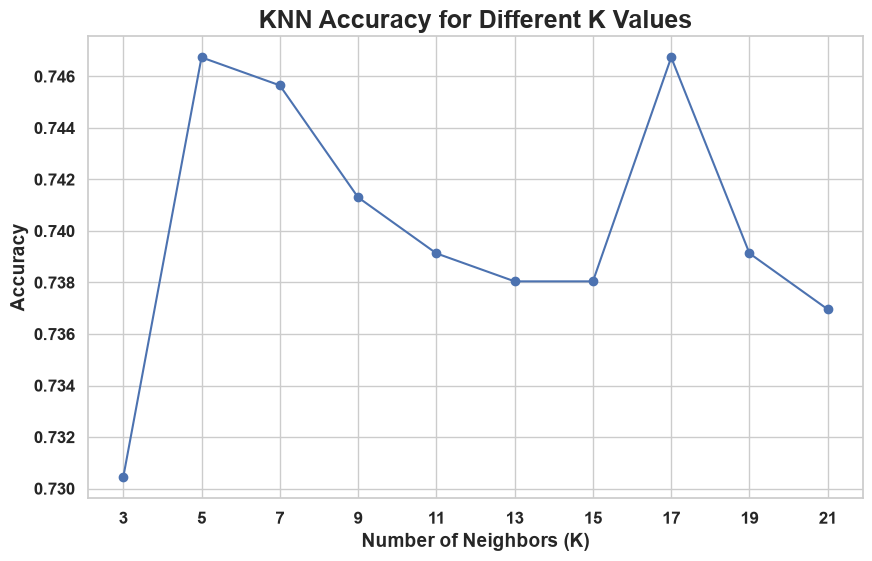

In [60]:
# Plot KNN accuracy for different K values

plt.figure(figsize=(10, 6))
plt.plot(list(k_values), knn_scores, marker='o')

plt.title("KNN Accuracy for Different K Values", fontsize=18, fontweight="bold")
plt.xlabel("Number of Neighbors (K)", fontsize=14, fontweight="bold")
plt.ylabel("Accuracy", fontsize=14, fontweight="bold")
plt.xticks(list(k_values), fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")
plt.grid(True)
plt.show()

<div dir="rtl" style=" max-width: 950px; margin: 15px auto 30px auto; padding: 18px 30px; text-align: right; font-size: 20px; line-height: 1.8; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 14px; "><b>מסקנה:</b> בגרף ניתן לראות כיצד ערך ה־accuracy משתנה עבור ערכי K שונים. נבחר את ערך ה־K שנותן את הדיוק הגבוה ביותר על נתוני הבדיקה.</div>

In [61]:
# Choose the best K

best_index = np.argmax(knn_scores)
best_k = list(k_values)[best_index]
best_score = knn_scores[best_index]

print("Best K:", best_k)
print("Best accuracy:", round(best_score, 4))

# Train final KNN model
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

# Predict test data
knn_predictions = knn_model.predict(X_test_scaled)

print("Final KNN model trained successfully")

Best K: 5
Best accuracy: 0.7467
Final KNN model trained successfully


Confusion Matrix:
[[351 109]
 [124 336]]


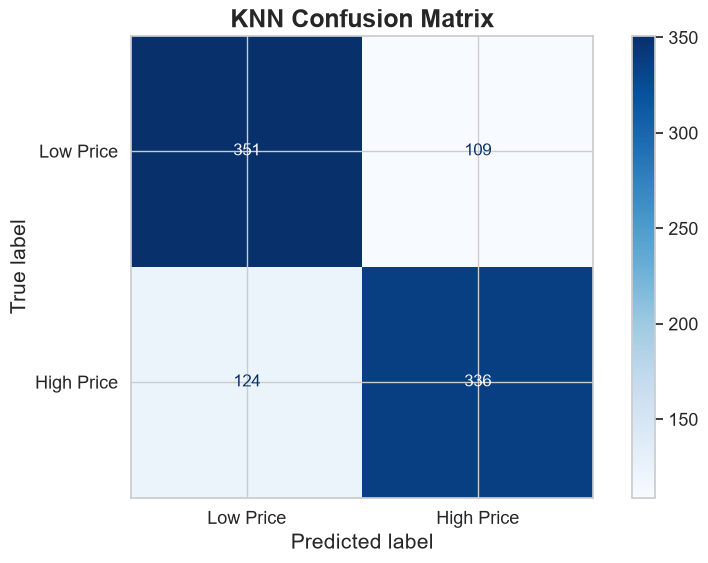

In [62]:
# Confusion Matrix for KNN

cm = confusion_matrix(y_test, knn_predictions)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low Price", "High Price"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("KNN Confusion Matrix", fontsize=18, fontweight="bold")
plt.show()

<div dir="rtl" style=" max-width: 950px; margin: 15px auto 30px auto; padding: 18px 30px; text-align: right; font-size: 20px; line-height: 1.8; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 14px; "><b>מסקנה:</b> מטריצת הבלבול מציגה כמה בתים סווגו נכון וכמה בתים סווגו בצורה שגויה. האלכסון הראשי מציג את התחזיות הנכונות, ושאר התאים מציגים טעויות סיווג.</div>

In [63]:
# Classification Report for KNN

print("Classification Report:")
print(classification_report(y_test, knn_predictions, target_names=["Low Price", "High Price"], digits=4))

Classification Report:
              precision    recall  f1-score   support

   Low Price     0.7389    0.7630    0.7508       460
  High Price     0.7551    0.7304    0.7425       460

    accuracy                         0.7467       920
   macro avg     0.7470    0.7467    0.7467       920
weighted avg     0.7470    0.7467    0.7467       920



<div dir="rtl" style=" max-width: 950px; margin: 25px auto; padding: 25px 40px; text-align: right; font-size: 21px; line-height: 1.9; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 16px; ">
<h2 style="color:#000000; font-weight:800;">הסבר מדדי הביצוע</h2>
<p><b>Accuracy</b> - אחוז התחזיות הנכונות מתוך כל הדוגמאות.</p>
<p><b>Precision</b> - מתוך כל הדוגמאות שהמודל סיווג למחלקה מסוימת, כמה באמת שייכות למחלקה זו.</p>
<p><b>Recall</b> - מתוך כל הדוגמאות שבאמת שייכות למחלקה מסוימת, כמה המודל הצליח לזהות נכון.</p>
<p><b>F1-score</b> - מדד משולב שמאזן בין Precision לבין Recall.</p>
</div>

<div dir="rtl" style=" max-width: 950px; margin: 15px auto 30px auto; padding: 18px 30px; text-align: right; font-size: 20px; line-height: 1.8; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 14px; "><b>סיכום מודל KNN:</b> לאחר בדיקת מספר ערכים של K, בחרנו את הערך שנתן את רמת הדיוק הטובה ביותר. מודל KNN הצליח לחזות את רמת המחיר של הבית בצורה סבירה לפי המאפיינים הפיזיים של הבית.</div>

<div dir="rtl" style=" max-width: 950px; margin: 25px auto; padding: 25px 40px; text-align: right; font-size: 21px; line-height: 1.9; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 16px; ">

<h1 style="color:#000000; font-weight:800;">10. אימון מודל ANN</h1>

<p>
בשלב זה נפעיל מודל <b>ANN</b>, שהוא מודל של רשת נוירונים מלאכותית.
המודל מקבל את מאפייני הבית ומנסה לחזות האם הבית שייך לקבוצת מחיר נמוך או לקבוצת מחיר גבוה.
</p>

<p>
בפרויקט זה נשתמש ב־<b>TensorFlow / Keras</b> כדי לבנות את הרשת.
נבדוק את ביצועי המודל בעזרת <b>Accuracy</b> ו־<b>Loss</b>.
</p>

</div>

In [64]:
# ANN model using TensorFlow / Keras

data_frame = df.copy()

# Split features and target
X_ann = data_frame.drop(['Price_Level'], axis=1).to_numpy()
y_ann = data_frame['Price_Level'].to_numpy()

# Convert target column to categorical format
# 0 -> [1, 0]
# 1 -> [0, 1]
y_ann_cat = to_categorical(y_ann)

# Split data into train and test
X_train_ann, X_test_ann, y_train_ann, y_test_ann = train_test_split(
    X_ann,
    y_ann_cat,
    test_size=0.20,
    random_state=41,
    stratify=y_ann
)

# Normalize data
scaler_ann = MinMaxScaler()
X_train_ann = scaler_ann.fit_transform(X_train_ann)
X_test_ann = scaler_ann.transform(X_test_ann)

# Build ANN model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_ann.shape[1],)),
    Dense(32, activation='relu'),
    Dense(2, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train_ann,
    y_train_ann,
    epochs=10,
    shuffle=True,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10


c:\Users\Mhmd Rayan\meWork\House-Price-Prediction-ML\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6841 - loss: 0.6206 - val_accuracy: 0.7201 - val_loss: 0.5765
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7493 - loss: 0.5349 - val_accuracy: 0.7147 - val_loss: 0.5337
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7575 - loss: 0.5118 - val_accuracy: 0.7405 - val_loss: 0.5197
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7602 - loss: 0.5057 - val_accuracy: 0.7364 - val_loss: 0.5429
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7619 - loss: 0.5062 - val_accuracy: 0.7432 - val_loss: 0.5149
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7585 - loss: 0.5037 - val_accuracy: 0.7514 - val_loss: 0.5115
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7653 - loss: 0.4983 - val_accuracy: 0.7391 - val_loss: 0.5129
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7660 - loss: 0.4968 - val_accuracy: 0.7432 - val_loss: 0.5137
Epo

In [65]:
# Evaluate ANN model

ann_test_loss, ann_test_accuracy = model.evaluate(X_test_ann, y_test_ann, verbose=0)
ann_train_loss, ann_train_accuracy = model.evaluate(X_train_ann, y_train_ann, verbose=0)

print("ANN Train Loss:", round(ann_train_loss, 4))
print("ANN Train Accuracy:", round(ann_train_accuracy, 4))
print("ANN Test Loss:", round(ann_test_loss, 4))
print("ANN Test Accuracy:", round(ann_test_accuracy, 4))

ANN Train Loss: 0.497
ANN Train Accuracy: 0.7617
ANN Test Loss: 0.4877
ANN Test Accuracy: 0.7511


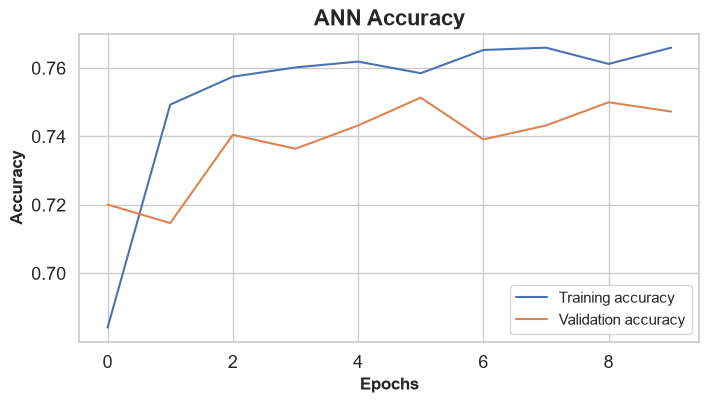

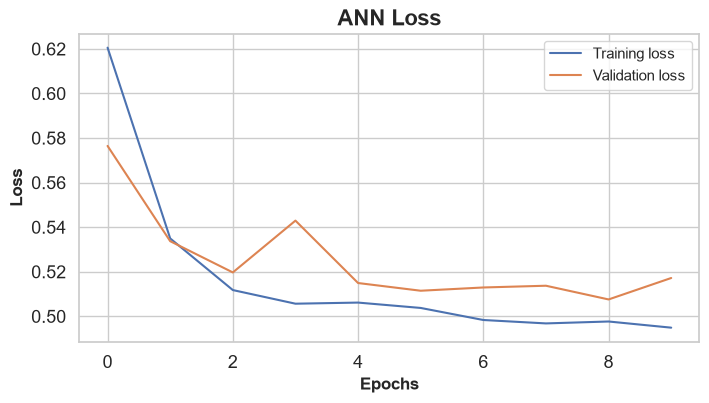

In [66]:
# Plot ANN accuracy and loss

plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')

plt.xlabel('Epochs', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('ANN Accuracy', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')

plt.xlabel('Epochs', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.title('ANN Loss', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()

In [67]:
# ANN classification report

ann_predictions_prob = model.predict(X_test_ann)
ann_predictions = np.argmax(ann_predictions_prob, axis=1)

y_test_ann_labels = np.argmax(y_test_ann, axis=1)

print("ANN Classification Report:")
print(classification_report(
    y_test_ann_labels,
    ann_predictions,
    target_names=["Low Price", "High Price"],
    digits=4
))

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
ANN Classification Report:
              precision    recall  f1-score   support

   Low Price     0.7260    0.8065    0.7642       460
  High Price     0.7824    0.6957    0.7365       460

    accuracy                         0.7511       920
   macro avg     0.7542    0.7511    0.7503       920
weighted avg     0.7542    0.7511    0.7503       920



<div dir="rtl" style=" max-width: 950px; margin: 25px auto; padding: 25px 40px; text-align: right; font-size: 21px; line-height: 1.9; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 16px; ">

<h2 style="color:#000000; font-weight:800;">סיכום מודל ANN</h2>

<p>
בשלב זה בנינו מודל ANN בעזרת TensorFlow ו־Keras.
המודל כולל שתי שכבות נסתרות: שכבה אחת עם 64 נוירונים ושכבה נוספת עם 32 נוירונים.
בשכבות אלו השתמשנו בפונקציית ההפעלה <b>ReLU</b>.
</p>

<p>
בשכבת הפלט השתמשנו ב־<b>softmax</b>, מכיוון שיש לנו שתי מחלקות:
מחיר נמוך ומחיר גבוה.
בנוסף, השתמשנו ב־<b>categorical_crossentropy</b> כפונקציית Loss, כי זו בעיית סיווג.
</p>

<p>
בדקנו את ביצועי המודל בעזרת <b>Accuracy</b> ו־<b>Loss</b>.
כאשר ה־Loss יורד במהלך האימון, זה אומר שהמודל לומד ומשפר את עצמו.
כאשר ה־Accuracy עולה, זה אומר שהמודל מצליח לסווג יותר בתים בצורה נכונה.
</p>

</div>

<div dir="rtl" style=" max-width: 950px; margin: 25px auto; padding: 25px 40px; text-align: right; font-size: 21px; line-height: 1.9; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 16px; ">
<h1 style="color:#000000; font-weight:800;">11. השוואת מודלים</h1>
<p>בשלב זה נשווה בין שני המודלים שהפעלנו בפרויקט: <b>KNN</b> ו־<b>ANN</b>. ההשוואה נעשית לפי Accuracy על נתוני הבדיקה.</p>
</div>

In [68]:
# Compare KNN and ANN results

knn_test_accuracy = knn_model.score(X_test_scaled, y_test)

comparison_results = pd.DataFrame({
    "Model": ["KNN", "ANN"],
    "Test Accuracy": [knn_test_accuracy, ann_test_accuracy]
})

comparison_results

,Model,Test Accuracy
0,KNN,0.746739
1,ANN,0.751087


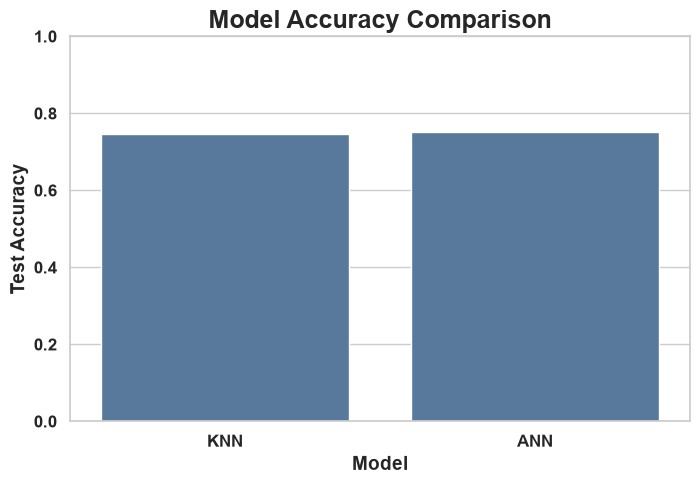

In [69]:
# Compare model accuracy

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_results, x="Model", y="Test Accuracy", color="#4C78A8")

plt.title("Model Accuracy Comparison", fontsize=18, fontweight="bold")
plt.xlabel("Model", fontsize=14, fontweight="bold")
plt.ylabel("Test Accuracy", fontsize=14, fontweight="bold")
plt.ylim(0, 1)
plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

plt.show()

<div dir="rtl" style=" max-width: 950px; margin: 15px auto 30px auto; padding: 18px 30px; text-align: right; font-size: 20px; line-height: 1.8; background-color: #ffffff; color: #111111; font-weight: 600; border: 1px solid #d0d0d0; border-radius: 14px; "><b>מסקנה:</b> ההשוואה בין KNN לבין ANN מראה איזה מודל הצליח לקבל Accuracy גבוה יותר על נתוני הבדיקה. שני המודלים ניסו לחזות האם בית שייך לקבוצת מחיר נמוך או גבוה לפי המאפיינים הפיזיים שלו.</div>

<div dir="rtl" style="
    max-width: 950px;
    margin: 30px auto;
    padding: 30px 45px;
    text-align: right;
    font-size: 21px;
    line-height: 1.9;
    background-color: #ffffff;
    color: #111111;
    font-weight: 600;
    border: 2px solid #d0d0d0;
    border-radius: 18px;
">

<h1 style="color:#000000; font-weight:800; text-align:center;">סיכום ורפלקציה</h1>

<h2 style="color:#000000; font-weight:800;">מסקנות מהפרויקט</h2>

<p>
בפרויקט זה בדקתי האם ניתן לחזות אם בית שייך לקבוצת מחיר גבוה או מחיר נמוך לפי מאפיינים פיזיים של הבית.
לשם כך השתמשתי בקובץ נתונים של בתים, ביצעתי חקר נתונים, ניקוי נתונים, הנדסת מאפיינים,
בדיקת קורלציה, נירמול נתונים ואימון מודלים של למידת מכונה.
</p>

<p>
בתהליך העבודה מחקתי את העמודות <b>date</b>, <b>street</b>, <b>city</b>, <b>statezip</b>, <b>country</b>,
כי בפרויקט זה רציתי להתמקד במאפיינים הפיזיים של הבית ולא במאפיינים טקסטואליים או מיקום מפורט.
לא מחקתי שורות מהנתונים.
</p>

<p>
הפכתי את עמודת <b>price</b> מבעיה של רגרסיה לבעיה של סיווג באמצעות יצירת עמודה חדשה בשם <b>Price_Level</b>.
החלוקה נעשתה לפי החציון של המחיר: מחיר נמוך או שווה לחציון קיבל ערך 0, ומחיר גבוה מהחציון קיבל ערך 1.
</p>

<p>
מהגרפים ומבדיקת הקורלציה ניתן לראות שמאפיינים כמו <b>sqft_living</b>, <b>sqft_above</b>, <b>bathrooms</b> ו־<b>bedrooms</b>
קשורים לרמת המחיר של הבית. כלומר, בתים גדולים יותר ובתים עם יותר חדרי רחצה נוטים להיות בקבוצת מחיר גבוה.
</p>

<p>
בשלב המודלים הפעלתי את אלגוריתם <b>KNN</b> ובחרתי את מספר השכנים המתאים ביותר לפי תוצאת ה־Accuracy.
בנוסף, הפעלתי מודל <b>ANN</b> ובדקתי את הביצועים שלו בעזרת Accuracy ו־Loss.
</p>

<h2 style="color:#000000; font-weight:800;">רפלקציה אישית</h2>

<p>
במהלך העבודה למדתי איך לבצע תהליך מלא של מדעי הנתונים מתחילתו ועד סופו.
למדתי כיצד לקרוא קובץ נתונים, להבין את מבנה הטבלה, לבדוק ערכים חסרים,
לבצע ויזואליזציה, לבדוק קורלציה ולהכין את הנתונים ללמידת מכונה.
</p>

<p>
אחד האתגרים המרכזיים בפרויקט היה להפוך את בעיית חיזוי המחיר מבעיה של רגרסיה לבעיה של סיווג,
כדי להתאים את הפרויקט לדרישות של KNN ו־ANN. בנוסף, היה חשוב להימנע ממצב שבו המודל מקבל את עמודת המחיר המקורית,
כי זה היה גורם למודל לקבל את התשובה האמיתית.
</p>

<p>
החלק המעניין ביותר עבורי היה לראות דרך הגרפים והקורלציה אילו מאפיינים באמת משפיעים על רמת המחיר.
בנוסף, היה מעניין להשוות בין KNN לבין ANN ולראות כיצד כל מודל מתמודד עם אותה בעיית סיווג.
</p>

<p>
לסיכום, הפרויקט הראה שניתן לחזות בצורה סבירה אם בית נמצא בקבוצת מחיר נמוך או גבוה לפי מאפיינים פיזיים של הבית.
העבודה עזרה לי להבין טוב יותר את השלבים החשובים בלמידת מכונה ואת החשיבות של הכנת הנתונים לפני בניית המודל.
</p>

</div>